# 07 · Ablations & Runtime

Closes the three gaps the paper outline flags:

1. **Without the alias map** — how much does name standardisation actually contribute?
2. **Routing ablation** — direct-only vs tblastn-only vs the hybrid router.
3. **Runtime** — throughput per virus, split by branch.

Plus **(4) rescue ablation**, using the lifter's own pre-rescue coordinates.

All four use the shipped functions (`run_pipeline` via `run_production_pipeline_against_truth`,
`run_tblastn_against_truth`, `direct_extract_with_alias`, `lift_all_tblastn`) and the shared metric —
nothing about the tool is re-implemented here.

## Inputs

All three virus datasets.

In [1]:
from pathlib import Path
import sys, time
from copy import deepcopy

import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path.cwd()
for candidate in [ROOT, *ROOT.parents]:
    if (candidate / "app" / "src").exists():
        ROOT = candidate
        break
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

DATA   = ROOT / "app" / "data"
CONFIG = ROOT / "app" / "config"

FMD_REF    = DATA / "FMD"  / "FMD_ref_test.gb"
FMD_QUERY  = DATA / "FMD"  / "FMD_100seq_anno.gb"
PRRS_REF   = DATA / "PRRS" / "PRRS_ref_test.gb"
PRRS_QUERY = DATA / "PRRS" / "PRRS_100seq_anno.gb"
PED_REF    = DATA / "PED"  / "PED_ref_1.gb"
PED_QUERY  = DATA / "PED"  / "PED_100seqs.gb"

PAIRS = {"fmd": (FMD_REF, FMD_QUERY), "prrs": (PRRS_REF, PRRS_QUERY), "ped": (PED_REF, PED_QUERY)}
RUN_FULL = True

In [2]:
# outputs land inside this unit folder so figures/tables sit next to the notebook
UNIT_DIR = ROOT / "app" / "validation" / "07_ablation_runtime"
OUT = UNIT_DIR / "outputs"
OUT.mkdir(parents=True, exist_ok=True)
print("outputs ->", OUT)

outputs -> /root/work/app/validation/07_ablation_runtime/outputs


## (1) Without the alias map

The tool's first claim is that GenBank gene names are inconsistent and the alias map fixes them.
The ablation that matches that claim is a **name-resolution** one, not a coordinate one: for each
annotated truth feature, would a name-based query ("give me ORF5 for every record") find it?

- **with alias** — names resolved through the per-virus alias config
- **without alias** — the raw `/gene`, `/product`, … strings exactly as submitted

Same records, same features; only the name resolution changes. This is the number behind the
use case in the brief: extracting one CDS across a whole corpus.

In [3]:
from app.validation._shared.validation_utils import (
    load_reference_bundle, load_genbank_records, parse_features_for_type,
    run_tblastn_against_truth, run_production_pipeline_against_truth,
    parse_truth_features, dedupe_truth_by_name, compare_predictions_to_truth,
    lifted_to_rows, ref_codon_checkable_genes,
)
from app.src.alias.gene_alias import apply_alias_to_features
from app.src.features.annotation_strategy import get_strategy
from app.src.features.direct_extractor import direct_extract_with_alias
from app.src.lifting.tblastn_lifter import lift_all_tblastn
from app.src.pipeline import PipelineConfig

CFG = PipelineConfig()

alias_rows = []
for label, (ref_path, query_path) in PAIRS.items():
    bundle = load_reference_bundle(ref_path)
    R = {f["name"] for f in bundle["features"]}
    ftype = bundle["feature_type"]
    for rec in load_genbank_records(query_path):
        raw = parse_features_for_type(rec, ftype)
        if not raw:
            continue
        normalised = apply_alias_to_features([dict(f) for f in raw], bundle["alias_lookup"])
        for f_raw, f_norm in zip(raw, normalised):
            alias_rows.append({
                "virus": label, "record_id": rec.id,
                "raw_name": f_raw.get("name"),
                "resolved_name": f_norm.get("name"),
                "hits_reference_without_alias": f_raw.get("name") in R,
                "hits_reference_with_alias":    f_norm.get("name") in R,
            })

alias_df = pd.DataFrame(alias_rows)
alias_df.to_csv(OUT / "ablation_alias_per_feature.tsv", sep="\t", index=False)

abl_alias = (alias_df.groupby("virus")
             .agg(features=("raw_name", "size"),
                  without_alias=("hits_reference_without_alias", "sum"),
                  with_alias=("hits_reference_with_alias", "sum")).reset_index())
abl_alias["without_alias_pct"] = (abl_alias["without_alias"]/abl_alias["features"]*100).round(2)
abl_alias["with_alias_pct"]    = (abl_alias["with_alias"]/abl_alias["features"]*100).round(2)
abl_alias["gain_pp"]           = (abl_alias["with_alias_pct"] - abl_alias["without_alias_pct"]).round(2)
abl_alias.to_csv(OUT / "ablation_alias.tsv", sep="\t", index=False)
print(abl_alias.to_string(index=False))
print("\nmost common raw names the alias map had to rescue:")
print(alias_df[~alias_df.hits_reference_without_alias & alias_df.hits_reference_with_alias]
        .groupby(["virus","raw_name","resolved_name"]).size()
        .sort_values(ascending=False).head(15).to_string())

virus  features  without_alias  with_alias  without_alias_pct  with_alias_pct  gain_pp
  fmd      1178            421        1172              35.74           99.49    63.75
  ped       601            361         505              60.07           84.03    23.96
 prrs       836            177         797              21.17           95.33    74.16

most common raw names the alias map had to rescue:
virus  raw_name                      resolved_name
fmd    3C                            3Cpro            50
       3D                            3Dpol            50
       2B peptide                    2B               48
       2C peptide                    2C               48
       3A peptide                    3A               48
       VP4 peptide                   VP4              48
       VP3 peptide                   VP3              48
       VP2 peptide                   VP2              48
       VP1 peptide                   VP1              48
       2A peptide                   

## (2) Routing ablation — direct-only vs tblastn-only vs hybrid

Three modes on the same records, scored identically (truth-anchored `R ∩ truth`, per-gene codon
exemption):

- **direct-only** — force `direct_extract_with_alias` on every record. A record whose annotation is
  absent or unusable yields nothing.
- **tblastn-only** — force the lifter on every record (this is what `02_lifting_accuracy` reports).
- **hybrid** — the shipped router (`run_pipeline`) decides per record.

In [4]:
def truth_cov(bundle, R, rec, preds, codon_required, label, mode):
    truth, _ = parse_truth_features(rec, bundle["alias_lookup"], bundle["feature_type"],
                                    filter_nested=False, target_names=sorted(R), keep_extra_names=[])
    truth = dedupe_truth_by_name(truth)
    if not truth:
        return []
    if preds:
        cmp = compare_predictions_to_truth(preds, truth, codon_required_names=codon_required)
        ok = set(cmp.loc[cmp["coord_correct"], "pred_name"])
        ex = set(cmp.loc[cmp["exact_match"], "pred_name"])
    else:
        ok, ex = set(), set()
    return [{"virus": label, "mode": mode, "record_id": rec.id, "gene": t["name"],
             "found": t["name"] in ok, "exact": t["name"] in ex} for t in truth]

route_cov, timings = [], []
for label, (ref_path, query_path) in PAIRS.items():
    bundle = load_reference_bundle(ref_path)
    R = {f["name"] for f in bundle["features"]}
    ftype = bundle["feature_type"]
    codon_required = ref_codon_checkable_genes(bundle)
    records = load_genbank_records(query_path)

    t_direct = t_tblastn = 0.0
    n_direct = n_tblastn = 0
    for rec in records:
        # --- direct-only ---
        strategy, qtype = get_strategy(rec, bundle["alias_lookup"], allowed_types=(ftype,) if ftype else None)
        t0 = time.perf_counter()
        d_feats = direct_extract_with_alias(query_record=rec, query_feature_type=qtype or ftype,
                                            ref_features=bundle["features"],
                                            alias_lookup=bundle["alias_lookup"]) if (qtype or ftype) else []
        t_direct += time.perf_counter() - t0; n_direct += 1
        route_cov += truth_cov(bundle, R, rec, lifted_to_rows(rec.id, d_feats, "direct"),
                               codon_required, label, "direct_only")

        # --- tblastn-only ---
        t0 = time.perf_counter()
        l_feats = lift_all_tblastn(ref_features=bundle["features"], ref_record=bundle["record"],
                                   query_record=rec, min_coverage=CFG.min_coverage,
                                   min_identity=CFG.min_identity, evalue=CFG.evalue,
                                   rescue_window=CFG.rescue_window, validate_codons=(ftype == "CDS"))
        t_tblastn += time.perf_counter() - t0; n_tblastn += 1
        route_cov += truth_cov(bundle, R, rec, lifted_to_rows(rec.id, l_feats, "tblastn"),
                               codon_required, label, "tblastn_only")

        # --- hybrid: whichever branch the shipped router picked ---
        picked = d_feats if strategy == "direct" else l_feats
        route_cov += truth_cov(bundle, R, rec, lifted_to_rows(rec.id, picked, strategy),
                               codon_required, label, "hybrid")

    timings.append({"virus": label, "records": len(records),
                    "direct_total_s": round(t_direct, 3), "tblastn_total_s": round(t_tblastn, 3),
                    "direct_ms_per_record": round(t_direct/max(n_direct,1)*1000, 2),
                    "tblastn_ms_per_record": round(t_tblastn/max(n_tblastn,1)*1000, 2)})
    print(f"{label}: done ({len(records)} records)")

route_df = pd.DataFrame(route_cov)
route_df.to_csv(OUT / "ablation_routing_coverage.tsv", sep="\t", index=False)

b = route_df.assign(bucket=lambda d: d.apply(
        lambda r: "exact" if r["exact"] else ("coord_only" if r["found"] else "failed"), axis=1))
routing_summary = (b.pivot_table(index=["virus","mode"], columns="bucket", values="gene",
                                 aggfunc="size", fill_value=0)
                     .reindex(columns=["exact","coord_only","failed"], fill_value=0))
routing_summary["total"] = routing_summary.sum(axis=1)
routing_summary["accuracy_pct"] = ((routing_summary["exact"]+routing_summary["coord_only"])
                                   / routing_summary["total"]*100).round(2)
routing_summary = routing_summary.reset_index()
routing_summary.to_csv(OUT / "ablation_routing.tsv", sep="\t", index=False)
print(routing_summary.to_string(index=False))

fmd: done (100 records)


prrs: done (100 records)


ped: done (100 records)
virus         mode  exact  coord_only  failed  total  accuracy_pct
  fmd  direct_only   1172           0       0   1172        100.00
  fmd       hybrid   1172           0       0   1172        100.00
  fmd tblastn_only   1138          32       2   1172         99.83
  ped  direct_only    505           0       0    505        100.00
  ped       hybrid    505           0       0    505        100.00
  ped tblastn_only    500           4       1    505         99.80
 prrs  direct_only    795           0       1    796         99.87
 prrs       hybrid    795           0       1    796         99.87
 prrs tblastn_only    706          88       2    796         99.75


### (1b) Without the alias map — **end-to-end accuracy**, not just name matching

(1) above measures a *proxy*: whether an annotated feature's name matches a reference gene. A
reviewer will ask for the accuracy consequence. This cell runs the tool itself with an **empty alias
lookup** and scores it against the same truth.

Scope, stated explicitly: alias is removed from the **query side only**. The reference features keep
the canonical names `prepare_reference_features` assigned — stripping those too would confound this
ablation with a separate issue (e.g. the PRRSV reference carries no `/gene` qualifiers at all).
Truth also stays normalised, because truth is truth.

The expected — and diagnostic — result is an **asymmetry**: the alias map should matter enormously
for the *direct* branch (which reads names off the query) and not at all for the *tblastn* branch
(which takes names from the reference).

In [5]:
def score_with_lookup(bundle, R, ftype, codon_required, rec, lookup, mode):
    """Run the tool with `lookup` as its alias map; score against alias-normalised truth."""
    truth, _ = parse_truth_features(rec, bundle["alias_lookup"], ftype,
                                    filter_nested=False, target_names=sorted(R), keep_extra_names=[])
    truth = dedupe_truth_by_name(truth)
    if not truth:
        return []
    strategy, qtype = get_strategy(rec, lookup, allowed_types=(ftype,) if ftype else None)
    if strategy == "direct":
        feats = direct_extract_with_alias(rec, qtype or ftype, bundle["features"], lookup)
    else:
        feats = lift_all_tblastn(ref_features=bundle["features"], ref_record=bundle["record"],
                                 query_record=rec, min_coverage=CFG.min_coverage,
                                 min_identity=CFG.min_identity, evalue=CFG.evalue,
                                 rescue_window=CFG.rescue_window, validate_codons=(ftype == "CDS"))
    preds = lifted_to_rows(rec.id, feats, strategy)
    if preds:
        cmp = compare_predictions_to_truth(preds, truth, codon_required_names=codon_required)
        ok = set(cmp.loc[cmp["coord_correct"], "pred_name"])
    else:
        ok = set()
    return [{"virus": mode[0], "mode": mode[1], "record_id": rec.id, "gene": t["name"],
             "routed_to": strategy, "found": t["name"] in ok} for t in truth]

alias_e2e = []
for label, (ref_path, query_path) in PAIRS.items():
    bundle = load_reference_bundle(ref_path)
    R = {f["name"] for f in bundle["features"]}
    ftype = bundle["feature_type"]
    codon_required = ref_codon_checkable_genes(bundle)
    for rec in load_genbank_records(query_path):
        alias_e2e += score_with_lookup(bundle, R, ftype, codon_required, rec,
                                       bundle["alias_lookup"], (label, "with_alias"))
        alias_e2e += score_with_lookup(bundle, R, ftype, codon_required, rec,
                                       {}, (label, "without_alias"))
    print(f"{label}: done")

ae = pd.DataFrame(alias_e2e)
ae.to_csv(OUT / "ablation_alias_e2e_coverage.tsv", sep="\t", index=False)

s = (ae.groupby(["virus","mode"]).agg(total=("found","size"), correct=("found","sum")).reset_index())
s["accuracy_pct"] = (s["correct"]/s["total"]*100).round(2)
s.to_csv(OUT / "ablation_alias_e2e.tsv", sep="\t", index=False)
print("\nEND-TO-END accuracy, alias map on/off:")
print(s.pivot(index="virus", columns="mode", values="accuracy_pct").to_string())

print("\nwhich branch did each mode take? (this is where the asymmetry shows)")
print(ae.groupby(["virus","mode"])["routed_to"].value_counts().unstack(fill_value=0).to_string())

fmd: done


prrs: done


ped: done

END-TO-END accuracy, alias map on/off:
mode   with_alias  without_alias
virus                           
fmd        100.00          35.92
ped        100.00          71.49
prrs        99.87          22.24

which branch did each mode take? (this is where the asymmetry shows)
routed_to            direct
virus mode                 
fmd   with_alias       1172
      without_alias    1172
ped   with_alias        505
      without_alias     505
prrs  with_alias        796
      without_alias     796


### (2b) The other half of the routing ablation — records *without* usable annotation

⚠️ Read (2) carefully: every record in these datasets **is annotated**, so `direct_only` simply reads
the annotation back out — and that annotation *is* the truth. Its ~100 % is **circular by
construction**, not a measure of quality, and `hybrid` matches it only because the router correctly
chose `direct` every time.

The ablation only becomes informative on records the direct branch cannot serve. Re-running the same
three modes on **de-annotated copies** (the strip test from unit 09) supplies that half.

In [6]:
strip_cov = []
for label, (ref_path, query_path) in PAIRS.items():
    bundle = load_reference_bundle(ref_path)
    R = {f["name"] for f in bundle["features"]}
    ftype = bundle["feature_type"]
    codon_required = ref_codon_checkable_genes(bundle)
    for rec in load_genbank_records(query_path):
        bare = deepcopy(rec); bare.features = []          # genuinely unannotated input
        strategy, qtype = get_strategy(bare, bundle["alias_lookup"],
                                       allowed_types=(ftype,) if ftype else None)
        d_feats = direct_extract_with_alias(query_record=bare, query_feature_type=qtype or ftype,
                                            ref_features=bundle["features"],
                                            alias_lookup=bundle["alias_lookup"]) if (qtype or ftype) else []
        l_feats = lift_all_tblastn(ref_features=bundle["features"], ref_record=bundle["record"],
                                   query_record=bare, min_coverage=CFG.min_coverage,
                                   min_identity=CFG.min_identity, evalue=CFG.evalue,
                                   rescue_window=CFG.rescue_window, validate_codons=(ftype == "CDS"))
        # truth stays the ORIGINAL annotation (withheld from the tool)
        strip_cov += truth_cov(bundle, R, rec, lifted_to_rows(rec.id, d_feats, "direct"),
                               codon_required, label, "direct_only")
        strip_cov += truth_cov(bundle, R, rec, lifted_to_rows(rec.id, l_feats, "tblastn"),
                               codon_required, label, "tblastn_only")
        picked = d_feats if strategy == "direct" else l_feats
        strip_cov += truth_cov(bundle, R, rec, lifted_to_rows(rec.id, picked, strategy),
                               codon_required, label, "hybrid")

strip_route = pd.DataFrame(strip_cov)
strip_route.to_csv(OUT / "ablation_routing_unannotated_coverage.tsv", sep="\t", index=False)
sr = (strip_route.groupby(["virus","mode"]).agg(total=("found","size"), correct=("found","sum"))
        .reset_index())
sr["accuracy_pct"] = (sr["correct"]/sr["total"]*100).round(2)
sr.to_csv(OUT / "ablation_routing_unannotated.tsv", sep="\t", index=False)
print("Routing ablation on DE-ANNOTATED records (direct branch has nothing to read):")
print(sr.to_string(index=False))

Routing ablation on DE-ANNOTATED records (direct branch has nothing to read):
virus         mode  total  correct  accuracy_pct
  fmd  direct_only   1172        0          0.00
  fmd       hybrid   1172     1170         99.83
  fmd tblastn_only   1172     1170         99.83
  ped  direct_only    505        0          0.00
  ped       hybrid    505      504         99.80
  ped tblastn_only    505      504         99.80
 prrs  direct_only    796        0          0.00
 prrs       hybrid    796      794         99.75
 prrs tblastn_only    796      794         99.75


## (3) Runtime

In [7]:
timing_df = pd.DataFrame(timings)
timing_df["total_s"] = (timing_df["direct_total_s"] + timing_df["tblastn_total_s"]).round(2)
timing_df.to_csv(OUT / "runtime.tsv", sep="\t", index=False)
print(timing_df.to_string(index=False))
print("\nNote: direct and tblastn were BOTH run on every record for the ablation, so 'total_s' is"
      "\nthe cost of the experiment, not of a production run. Production cost per record is the"
      "\nbranch the router picks — see ms_per_record columns.")

virus  records  direct_total_s  tblastn_total_s  direct_ms_per_record  tblastn_ms_per_record  total_s
  fmd      100           0.011            4.750                  0.11                  47.50     4.76
 prrs      100           0.012            5.351                  0.12                  53.51     5.36
  ped      100           0.010            6.053                  0.10                  60.53     6.06

Note: direct and tblastn were BOTH run on every record for the ablation, so 'total_s' is
the cost of the experiment, not of a production run. Production cost per record is the
branch the router picks — see ms_per_record columns.


## (4) Rescue ablation — the lifter's own pre-rescue coordinates

`LiftedFeature` carries `raw_start` / `raw_end`: the merged-HSP span **before** start/stop rescue.
Scoring those against the same truth gives an exact rescue-OFF pass with **no change to the shipped
code and no re-implementation** — the OFF coordinates come from the lifter itself.

In [8]:
resc = []
for label, (ref_path, query_path) in PAIRS.items():
    bundle = load_reference_bundle(ref_path)
    R = {f["name"] for f in bundle["features"]}
    ftype = bundle["feature_type"]
    for rec in load_genbank_records(query_path):
        truth, _ = parse_truth_features(rec, bundle["alias_lookup"], ftype,
                                        filter_nested=False, target_names=sorted(R), keep_extra_names=[])
        truth = dedupe_truth_by_name(truth)
        if not truth: continue
        tm = {t["name"]: t for t in truth}
        lifted = lift_all_tblastn(ref_features=bundle["features"], ref_record=bundle["record"],
                                  query_record=rec, min_coverage=CFG.min_coverage,
                                  min_identity=CFG.min_identity, evalue=CFG.evalue,
                                  rescue_window=CFG.rescue_window, validate_codons=(ftype == "CDS"))
        for f in lifted:
            t = tm.get(f.name)
            if t is None: continue
            for mode, s, e in (("rescue_on", f.query_start, f.query_end),
                               ("rescue_off", getattr(f, "raw_start", None), getattr(f, "raw_end", None))):
                if s is None or e is None:
                    resc.append({"virus": label, "mode": mode, "record_id": rec.id,
                                 "gene": f.name, "found": False, "exact": False}); continue
                inter = max(0, min(e, t["end"]) - max(s, t["start"]) + 1)
                union = max(e, t["end"]) - min(s, t["start"]) + 1
                iou = inter/union if union else 0.0
                within = abs(s-t["start"]) <= 6 and abs(e-t["end"]) <= 6
                resc.append({"virus": label, "mode": mode, "record_id": rec.id, "gene": f.name,
                             "found": bool(iou >= 0.90 or within),
                             "exact": bool(s == t["start"] and e == t["end"])})

resc_df = pd.DataFrame(resc)
resc_df.to_csv(OUT / "ablation_rescue_coverage.tsv", sep="\t", index=False)
rescue = (resc_df.groupby(["virus","mode"]).agg(total=("found","size"), correct=("found","sum"),
                                                exact=("exact","sum")).reset_index())
rescue["accuracy_pct"] = (rescue["correct"]/rescue["total"]*100).round(2)
rescue["exact_pct"] = (rescue["exact"]/rescue["total"]*100).round(2)
rescue.to_csv(OUT / "ablation_rescue.tsv", sep="\t", index=False)
print(rescue.to_string(index=False))

# which genes does rescue actually save?
piv = resc_df.pivot_table(index=["virus","record_id","gene"], columns="mode", values="found", aggfunc="first")
saved = piv[(piv.get("rescue_on") == True) & (piv.get("rescue_off") == False)].reset_index()
saved.to_csv(OUT / "ablation_rescue_saved_genes.tsv", sep="\t", index=False)
print(f"\nrescue saves {len(saved)} gene calls:")
print(saved.groupby(["virus","gene"]).size().sort_values(ascending=False).head(12).to_string())

virus       mode  total  correct  exact  accuracy_pct  exact_pct
  fmd rescue_off   1172     1169   1094         99.74      93.34
  fmd  rescue_on   1172     1170   1138         99.83      97.10
  ped rescue_off    505      502      0         99.41       0.00
  ped  rescue_on    505      504    500         99.80      99.01
 prrs rescue_off    796      759      0         95.35       0.00
 prrs  rescue_on    796      794    706         99.75      88.69

rescue saves 38 gene calls:
virus  gene
prrs   ORF7    33
ped    ORF3     2
prrs   ORF3     2
fmd    2A       1


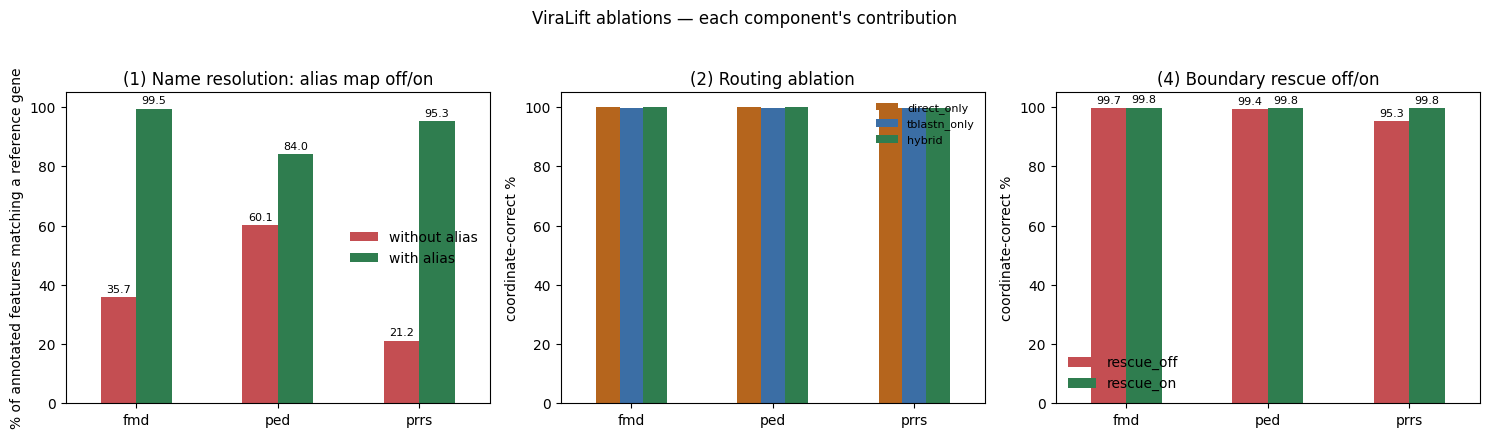

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))

p1 = abl_alias.set_index("virus")[["without_alias_pct","with_alias_pct"]]
p1.plot(kind="bar", ax=axes[0], rot=0, color=["#c44e52","#2f7d4f"])
axes[0].set_ylim(0,105); axes[0].set_title("(1) Name resolution: alias map off/on")
axes[0].set_ylabel("% of annotated features matching a reference gene"); axes[0].set_xlabel("")
axes[0].legend(["without alias","with alias"], frameon=False)
for c in axes[0].containers: axes[0].bar_label(c, fmt="%.1f", padding=2, fontsize=8)

p2 = routing_summary.pivot(index="virus", columns="mode", values="accuracy_pct")
p2 = p2.reindex(columns=[c for c in ["direct_only","tblastn_only","hybrid"] if c in p2.columns])
p2.plot(kind="bar", ax=axes[1], rot=0, color=["#b5651d","#3b6ea5","#2f7d4f"])
axes[1].set_ylim(0,105); axes[1].set_title("(2) Routing ablation"); axes[1].set_xlabel("")
axes[1].set_ylabel("coordinate-correct %"); axes[1].legend(frameon=False, fontsize=8)

p3 = rescue.pivot(index="virus", columns="mode", values="accuracy_pct")
p3 = p3.reindex(columns=[c for c in ["rescue_off","rescue_on"] if c in p3.columns])
p3.plot(kind="bar", ax=axes[2], rot=0, color=["#c44e52","#2f7d4f"])
axes[2].set_ylim(0,105); axes[2].set_title("(4) Boundary rescue off/on"); axes[2].set_xlabel("")
axes[2].set_ylabel("coordinate-correct %"); axes[2].legend(frameon=False)
for c in axes[2].containers: axes[2].bar_label(c, fmt="%.1f", padding=2, fontsize=8)

fig.suptitle("ViraLift ablations — each component's contribution", y=1.03)
fig.tight_layout(); fig.savefig(OUT / "ablation_summary.png", dpi=200, bbox_inches="tight")

## Interpretation

> Fill in after the run. Report each component separately — they answer different objections:
> **(1)** justifies the alias map, **(2)** justifies the router (direct-only should collapse on
> records without usable annotation; tblastn-only should be close to hybrid but slower),
> **(4)** justifies the rescue layer. Runtime belongs in Methods/Availability, not Results.

### (5) Uncertainty — bootstrap CIs and a paired test

Point estimates alone are not enough for an ablation table. Each contrast below is **paired**: the
same records, the same genes, one component toggled. So:

- **95 % CI** on the difference, by bootstrapping over **records** (the unit of independence — genes
  within a record are not independent).
- **Exact McNemar test** on the paired gene-level outcomes, for the direction of the effect.

In [10]:
import random
from math import comb

def paired_delta_ci(df, mode_a, mode_b, key=("virus","record_id","gene"), n_boot=2000, seed=20260819):
    """Bootstrap the accuracy difference (b - a) by resampling RECORDS with replacement."""
    piv = df.pivot_table(index=list(key), columns="mode", values="found", aggfunc="first").dropna()
    if mode_a not in piv.columns or mode_b not in piv.columns:
        return None
    piv = piv.reset_index()
    records = piv["record_id"].unique().tolist()
    by_rec = {r: g for r, g in piv.groupby("record_id")}
    rng = random.Random(seed)
    obs = (piv[mode_b].mean() - piv[mode_a].mean()) * 100
    deltas = []
    for _ in range(n_boot):
        pick = [by_rec[rng.choice(records)] for _ in range(len(records))]
        s = pd.concat(pick, ignore_index=True)
        deltas.append((s[mode_b].mean() - s[mode_a].mean()) * 100)
    deltas.sort()
    lo, hi = deltas[int(0.025*n_boot)], deltas[int(0.975*n_boot)]
    # exact McNemar on discordant pairs
    b = int(((piv[mode_a] == True) & (piv[mode_b] == False)).sum())   # a right, b wrong
    c = int(((piv[mode_a] == False) & (piv[mode_b] == True)).sum())   # b right, a wrong
    n = b + c
    if n == 0:
        p = 1.0
    else:
        k = min(b, c)
        p = min(1.0, 2 * sum(comb(n, i) for i in range(k+1)) / (2**n))
    return {"contrast": f"{mode_b} - {mode_a}", "delta_pp": round(obs, 2),
            "ci95_low": round(lo, 2), "ci95_high": round(hi, 2),
            "n_genes": len(piv), "discordant_a_only": b, "discordant_b_only": c,
            "mcnemar_p": (f"{p:.2e}" if p < 1e-4 else round(p, 4))}

rows = []
for virus in sorted(PAIRS):
    for src, a, b_, name in [
        (ae[ae.virus == virus], "without_alias", "with_alias", "alias map (end-to-end)"),
        (strip_route[strip_route.virus == virus], "direct_only", "hybrid", "router, unannotated records"),
        (route_df[route_df.virus == virus], "tblastn_only", "hybrid", "router, annotated records"),
        (resc_df[resc_df.virus == virus], "rescue_off", "rescue_on", "boundary rescue"),
    ]:
        r = paired_delta_ci(src, a, b_)
        if r: rows.append({"virus": virus, "component": name, **r})

ci = pd.DataFrame(rows)
ci.to_csv(OUT / "ablation_confidence_intervals.tsv", sep="\t", index=False)
print(ci.to_string(index=False))

# Rescue is mostly about EXACTNESS, not about crossing the coord-correct threshold.
# Repeat the paired contrast on exact_match to show that separately.
def paired_delta_ci_col(df, mode_a, mode_b, col, n_boot=2000, seed=20260819):
    piv = df.pivot_table(index=["record_id","gene"], columns="mode", values=col,
                         aggfunc="first").dropna().reset_index()
    if mode_a not in piv.columns or mode_b not in piv.columns:
        return None
    rng = random.Random(seed); records = piv["record_id"].unique().tolist()
    by_rec = {r: g for r, g in piv.groupby("record_id")}
    obs = (piv[mode_b].mean() - piv[mode_a].mean()) * 100
    deltas = []
    for _ in range(n_boot):
        s = pd.concat([by_rec[rng.choice(records)] for _ in range(len(records))], ignore_index=True)
        deltas.append((s[mode_b].mean() - s[mode_a].mean()) * 100)
    deltas.sort()
    b = int(((piv[mode_a] == True) & (piv[mode_b] == False)).sum())
    c = int(((piv[mode_a] == False) & (piv[mode_b] == True)).sum())
    n = b + c; k = min(b, c)
    p = 1.0 if n == 0 else min(1.0, 2 * sum(comb(n, i) for i in range(k+1)) / (2**n))
    return {"contrast": f"{mode_b} - {mode_a}", "metric": col, "delta_pp": round(obs, 2),
            "ci95_low": round(deltas[int(0.025*n_boot)], 2),
            "ci95_high": round(deltas[int(0.975*n_boot)], 2), "n_genes": len(piv),
            "discordant_a_only": b, "discordant_b_only": c,
            "mcnemar_p": (f"{p:.2e}" if p < 1e-4 else round(p, 4))}

rows2 = []
for virus in sorted(PAIRS):
    sub = resc_df[resc_df.virus == virus]
    for col in ("found", "exact"):
        r = paired_delta_ci_col(sub, "rescue_off", "rescue_on", col)
        if r: rows2.append({"virus": virus, "component": "boundary rescue", **r})
ci_rescue = pd.DataFrame(rows2)
ci_rescue.to_csv(OUT / "ablation_rescue_ci.tsv", sep="\t", index=False)
print("\nBoundary rescue — coordinate-correct vs exact-match, paired:")
print(ci_rescue.to_string(index=False))
print("\nReading: rescue changes coordinate-correctness only on PRRSV (ORF7); on all three viruses it"
      "\nchanges EXACTNESS, because a tblastn HSP stops at the last aligned codon and excludes the"
      "\nstop codon. Report the two metrics separately or the effect looks smaller than it is.")

virus                   component                   contrast  delta_pp  ci95_low  ci95_high  n_genes  discordant_a_only  discordant_b_only mcnemar_p
  fmd      alias map (end-to-end) with_alias - without_alias     64.08     57.03      71.34     1172                  0                751 1.69e-226
  fmd router, unannotated records       hybrid - direct_only     99.83     99.57     100.00     1172                  0               1170  0.00e+00
  fmd   router, annotated records      hybrid - tblastn_only      0.17      0.00       0.43     1172                  0                  2       0.5
  fmd             boundary rescue     rescue_on - rescue_off      0.09      0.00       0.26     1172                  0                  1       1.0
  ped      alias map (end-to-end) with_alias - without_alias     28.51     20.59      37.67      505                  0                144  8.97e-44
  ped router, unannotated records       hybrid - direct_only     99.80     99.40     100.00      505      


Boundary rescue — coordinate-correct vs exact-match, paired:
virus       component               contrast metric  delta_pp  ci95_low  ci95_high  n_genes  discordant_a_only  discordant_b_only mcnemar_p
  fmd boundary rescue rescue_on - rescue_off  found      0.09      0.00       0.26     1172                  0                  1       1.0
  fmd boundary rescue rescue_on - rescue_off  exact      3.75      2.90       4.68     1172                  0                 44  1.14e-13
  ped boundary rescue rescue_on - rescue_off  found      0.40      0.00       1.00      505                  0                  2       0.5
  ped boundary rescue rescue_on - rescue_off  exact     99.01     97.86      99.80      505                  0                500 6.11e-151
 prrs boundary rescue rescue_on - rescue_off  found      4.40      3.15       5.53      796                  0                 35  5.82e-11
 prrs boundary rescue rescue_on - rescue_off  exact     88.69     87.86      89.53      796       